CIFAR-10 DATA VISUALISATION 

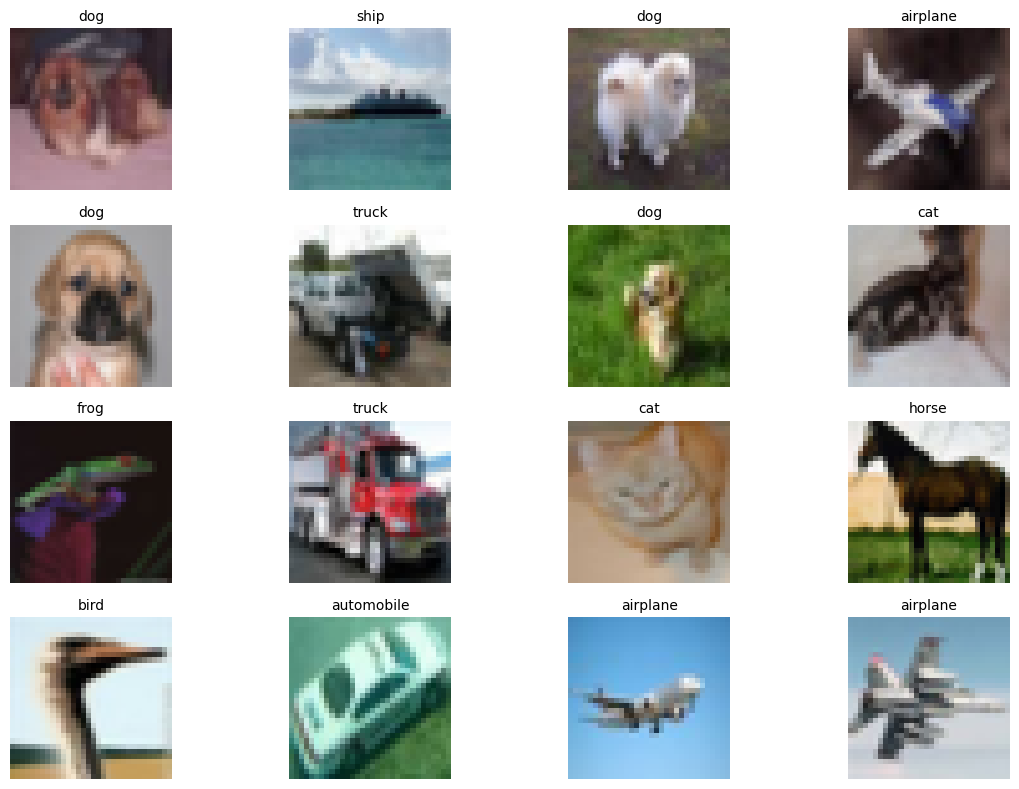

In [7]:
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

transform = transforms.Compose([transforms.ToTensor()])

cifar10_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
classes = cifar10_trainset.classes

def show_cifar10_images(dataset, num_images=16):
    loader = torch.utils.data.DataLoader(dataset, batch_size=num_images, shuffle=True)
    dataiter = iter(loader)
    images, labels = next(dataiter)

   
    plt.figure(figsize=(12, 8))
    for i in range(num_images):
        plt.subplot(4, 4, i + 1)
        img = images[i].numpy().transpose((1, 2, 0))  # CxHxW -> HxWxC
        plt.imshow(img)
        plt.title(classes[labels[i]], fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


import torch
show_cifar10_images(cifar10_trainset, num_images=16)



FEDMNIST DATA VISUALISATION

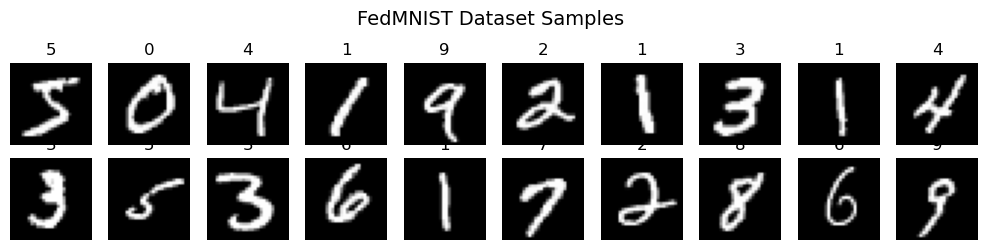

In [7]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# Load dataset
transform = transforms.ToTensor()
mnist_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Function to show samples
def show_fedmnist_samples(dataset, num_images=20):
    plt.figure(figsize=(10, 2.5))
    for i in range(num_images):
        image, label = dataset[i]
        image = image.squeeze()  # Shape: [28, 28]
        plt.subplot(2, num_images // 2, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(str(label))
        plt.axis("off")
    plt.suptitle("FedMNIST Dataset Samples ", fontsize=14)
    plt.tight_layout()
    plt.show()

# Visualize
show_fedmnist_samples(mnist_data)


EMNIST-CR DATA VISUALISATION

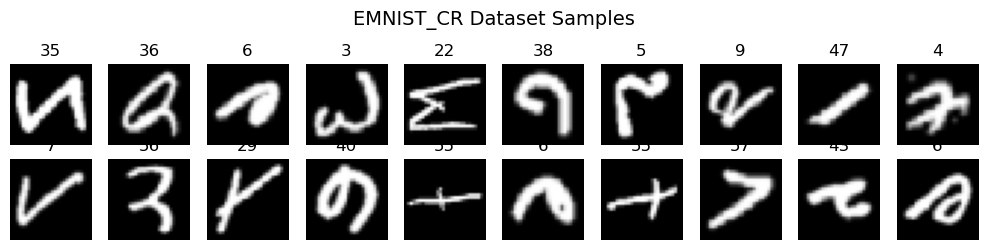

In [10]:
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

# Load EMNIST ByClass split
transform = transforms.ToTensor()
emnist_data = datasets.EMNIST(
    root="./data",
    split="byclass",
    train=True,
    download=True,
    transform=transform
)

# Function to show samples
def show_emnist_samples(dataset, num_images=20):
    plt.figure(figsize=(10, 2.5))
    for i in range(num_images):
        image, label = dataset[i]
        image = image.squeeze()  # Shape: [28, 28]
        plt.subplot(2, num_images // 2, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(str(label))
        plt.axis("off")
    plt.suptitle("EMNIST_CR Dataset Samples", fontsize=14)
    plt.tight_layout()
    plt.show()

# Visualize samples
show_emnist_samples(emnist_data)


MEDMNIST DATA VISUALISATION

In [7]:
pip install medmnist


Note: you may need to restart the kernel to use updated packages.


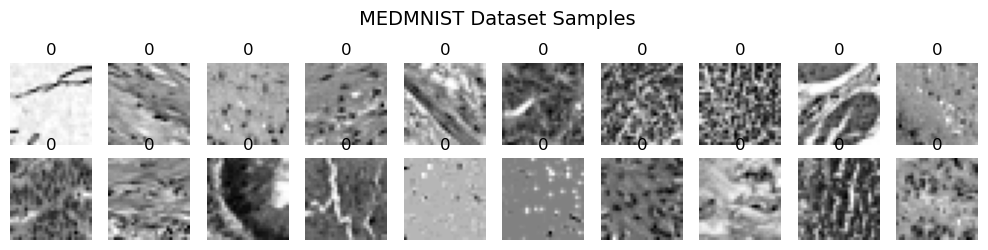

In [9]:
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from medmnist import INFO
from medmnist import PathMNIST  

# Choose a MedMNIST dataset 
data_flag = 'pathmnist'
download = True

# Get dataset info
info = INFO[data_flag]
DataClass = getattr(__import__('medmnist'), info['python_class'])

# Load the dataset (train split)
transform = transforms.Compose([transforms.ToTensor()])
medmnist_data = DataClass(split='train', transform=transform, download=download)

# Visualization function
def show_medmnist_samples(dataset, num_images=20):
    plt.figure(figsize=(10, 2.5))
    for i in range(num_images):
        image, label = dataset[i]
        if image.shape[0] == 3:  # Convert RGB to grayscale if needed
            image = image.mean(dim=0)
        else:
            image = image.squeeze()
        plt.subplot(2, num_images // 2, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(str(label.argmax().item()))  # For one-hot encoded labels
        plt.axis("off")
    plt.suptitle(" MEDMNIST Dataset Samples", fontsize=14)
    plt.tight_layout()
    plt.show()

# Visualize
show_medmnist_samples(medmnist_data)


FASHIONMNIST DATA VISUALISATION

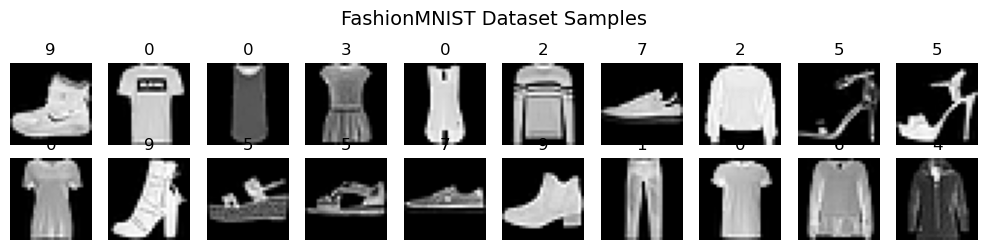

In [1]:
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torchvision.datasets import FashionMNIST

# Download and transform FashionMNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
fashion_data = FashionMNIST(root="./data", train=True, download=True, transform=transform)

# Visualization function
def show_fashionmnist_samples(dataset, num_images=20):
    plt.figure(figsize=(10, 2.5))
    for i in range(num_images):
        image, label = dataset[i]
        image = image.squeeze()  # Remove the channel dimension
        plt.subplot(2, num_images // 2, i + 1)
        plt.imshow(image, cmap="gray")
        plt.title(str(label))
        plt.axis("off")
    plt.suptitle("FashionMNIST Dataset Samples", fontsize=14)
    plt.tight_layout()
    plt.show()

# Visualize
show_fashionmnist_samples(fashion_data)


CODE FOR DATA DISTRIBUTION BAR CHART 

FEDMNIST DATASET

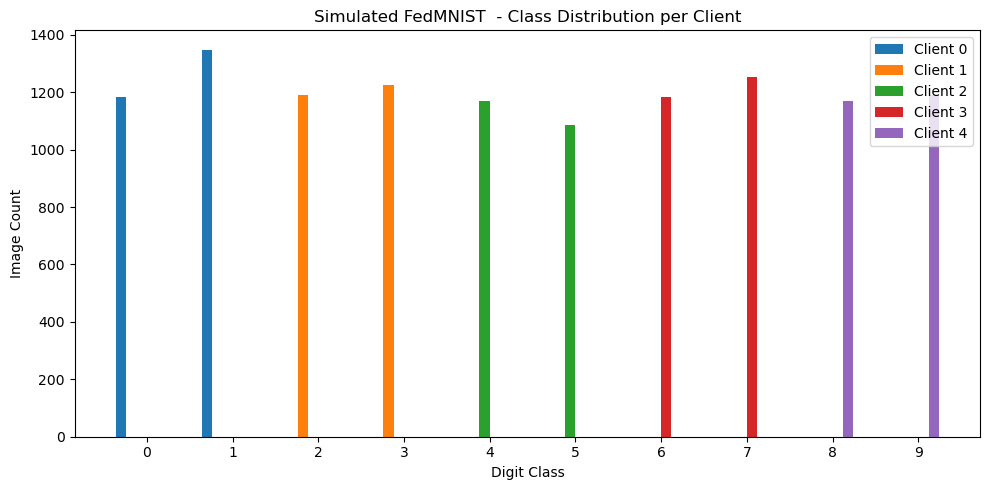

In [8]:
import torch
from torch.utils.data import Subset
from collections import Counter
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torchvision import transforms
import numpy as np

# Load  dataset
transform = transforms.ToTensor()
trainset = MNIST(root="./data", train=True, download=True, transform=transform)

# Parameters
num_clients = 5
classes_per_client = 2  # Each client gets 2 digits → 10 classes total

# Group indices by class
class_indices = {i: [] for i in range(10)}
for idx, (_, label) in enumerate(trainset):
    class_indices[label].append(idx)

# Assign classes to clients
client_indices = [[] for _ in range(num_clients)]
assigned_classes = np.array_split(np.arange(10), num_clients)

for client_id, classes in enumerate(assigned_classes):
    for cls in classes:
        client_indices[client_id].extend(class_indices[cls][:len(class_indices[cls]) // num_clients])
        class_indices[cls] = class_indices[cls][len(class_indices[cls]) // num_clients:]

# Plot class distribution
fig, ax = plt.subplots(figsize=(10, 5))
width = 0.12
labels = list(range(10))  # Digits 0-9

for i, indices in enumerate(client_indices):
    lbls = [trainset[idx][1] for idx in indices]
    count = Counter(lbls)
    values = [count.get(lbl, 0) for lbl in labels]
    ax.bar(np.array(labels) + i * width, values, width=width, label=f'Client {i}')

ax.set_xticks(np.array(labels) + width * num_clients / 2)
ax.set_xticklabels(labels)
ax.set_xlabel('Digit Class')
ax.set_ylabel('Image Count')
ax.set_title('Simulated FedMNIST  - Class Distribution per Client')
ax.legend()
plt.tight_layout()
plt.show()


CIFAR-10 DATASET

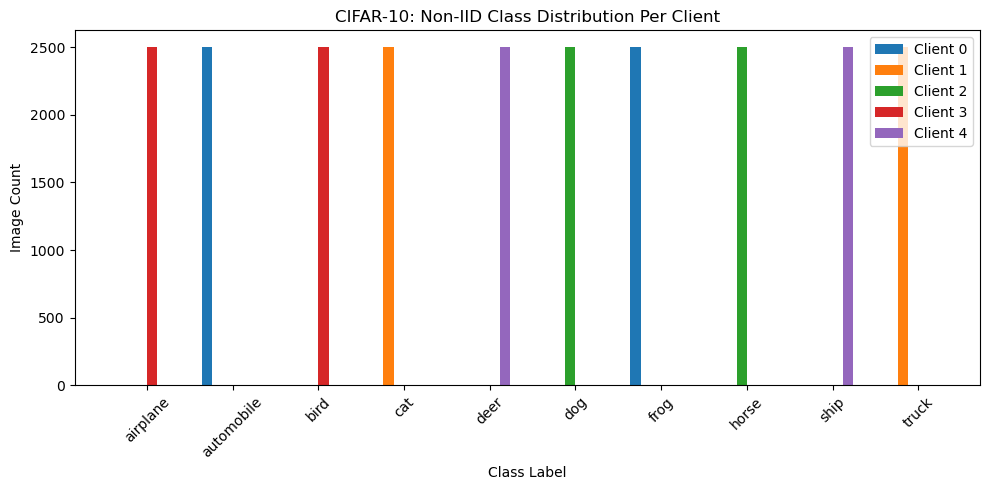

In [1]:
import torch
from torch.utils.data import Subset
from collections import Counter
import matplotlib.pyplot as plt
from torchvision.datasets import CIFAR10
from torchvision import transforms
import numpy as np

transform = transforms.ToTensor()
trainset = CIFAR10(root="./data", train=True, download=False, transform=transform)

def plot_class_distribution_cifar10_non_iid(num_clients=5, classes_per_client=2):
    # Group indices by class
    class_indices = {cls: [] for cls in range(10)}
    for idx, (_, label) in enumerate(trainset):
        class_indices[label].append(idx)
    
    # Shuffle indices in each class
    for cls in class_indices:
        np.random.shuffle(class_indices[cls])

    client_class_counts = []
    all_indices = []

    available_classes = list(range(10))
    np.random.shuffle(available_classes)

    for client_id in range(num_clients):
        # Assign specific subset of classes to each client
        assigned_classes = available_classes[client_id * classes_per_client:
                                             (client_id + 1) * classes_per_client]
        
        client_indices = []
        for cls in assigned_classes:
            num_samples = len(class_indices[cls]) // (num_clients // classes_per_client)
            client_indices.extend(class_indices[cls][:num_samples])
            class_indices[cls] = class_indices[cls][num_samples:]
        
        labels = [trainset[i][1] for i in client_indices]
        count = Counter(labels)
        client_class_counts.append(count)
        all_indices.append(client_indices)

    # Plot distribution
    fig, ax = plt.subplots(figsize=(10, 5))
    width = 0.12
    labels = list(range(10))
    class_names = trainset.classes
    for i, count in enumerate(client_class_counts):
        values = [count.get(lbl, 0) for lbl in labels]
        ax.bar([l + i * width for l in labels], values, width=width, label=f'Client {i}')

    ax.set_xticks([l + width * num_clients / 2 for l in labels])
    ax.set_xticklabels(class_names, rotation=45)
    ax.set_xlabel('Class Label')
    ax.set_ylabel('Image Count')
    ax.set_title('CIFAR-10: Non-IID Class Distribution Per Client')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_class_distribution_cifar10_non_iid(num_clients=5, classes_per_client=2)


EMNIST_CR DATASET

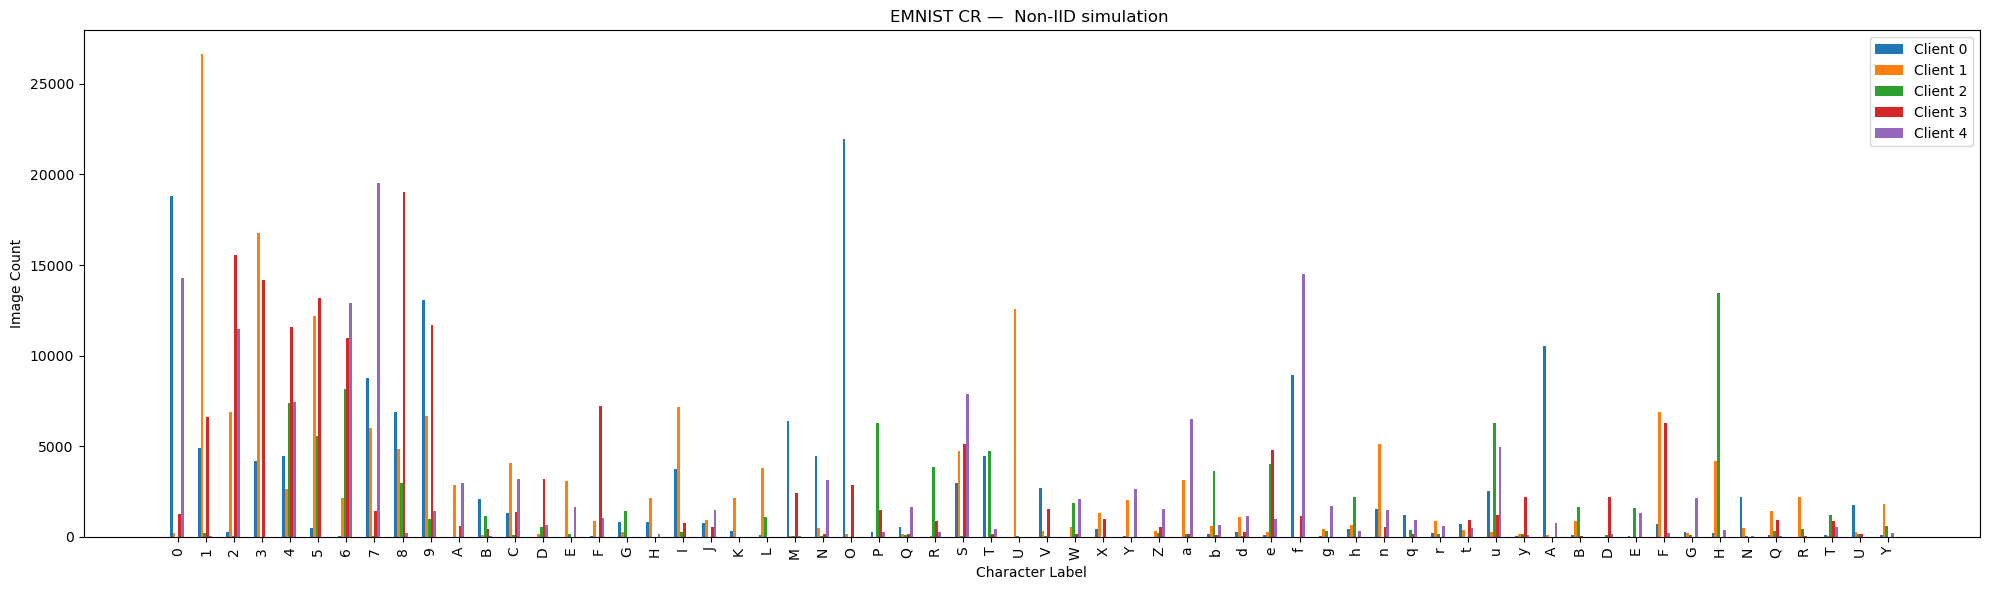

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from torchvision.datasets import EMNIST
from torchvision import transforms

# --- Config ---
NUM_CLIENTS = 5
ALPHA = 0.3       
SEED = 42
BUDGET_PER_CLIENT = None  

# Label -> printable char (62 classes)
label_to_char = {
    0:'0',1:'1',2:'2',3:'3',4:'4',5:'5',6:'6',7:'7',8:'8',9:'9',
    10:'A',11:'B',12:'C',13:'D',14:'E',15:'F',16:'G',17:'H',18:'I',19:'J',
    20:'K',21:'L',22:'M',23:'N',24:'O',25:'P',26:'Q',27:'R',28:'S',29:'T',
    30:'U',31:'V',32:'W',33:'X',34:'Y',35:'Z',
    36:'a',37:'b',38:'d',39:'e',40:'f',41:'g',42:'h',43:'n',44:'q',
    45:'r',46:'t',47:'u',48:'y',
    49:'A',50:'B',51:'D',52:'E',53:'F',54:'G',55:'H',56:'N',57:'Q',
    58:'R',59:'T',60:'U',61:'Y'
}

# --- Load EMNIST ByClass ---
transform = transforms.ToTensor()
dataset = EMNIST(root="./data", split="byclass", train=True, download=True, transform=transform)

# Group indices by class
num_classes = 62
class_to_indices = {c: [] for c in range(num_classes)}
for idx in range(len(dataset)):
    _, y = dataset[idx]
    class_to_indices[int(y)].append(idx)

# Shuffle indices inside each class for randomness
rng = np.random.default_rng(SEED)
for c in class_to_indices:
    rng.shuffle(class_to_indices[c])

# --- Dirichlet partitioning ---
client_indices = [[] for _ in range(NUM_CLIENTS)]

for c in range(num_classes):
    idxs = class_to_indices[c]
    n = len(idxs)
    if n == 0:
        continue

    # proportions for this class across clients
    props = rng.dirichlet([ALPHA] * NUM_CLIENTS)

    # turn proportions into integer splits that sum to n
    raw = props * n
    floors = np.floor(raw).astype(int)
    remainder = n - floors.sum()
    frac_order = np.argsort(-(raw - floors))  # descending by fractional part
    floors[frac_order[:remainder]] += 1
    splits = floors

    # slice the class indices and assign to clients
    start = 0
    for cid, take in enumerate(splits):
        if take > 0:
            client_indices[cid].extend(idxs[start:start+take])
            start += take


if BUDGET_PER_CLIENT is not None:
    for cid in range(NUM_CLIENTS):
        rng.shuffle(client_indices[cid])
        client_indices[cid] = client_indices[cid][:BUDGET_PER_CLIENT]

# --- Summarize per-client class distribution ---
client_counts = []
for cid in range(NUM_CLIENTS):
    labels = [int(dataset[i][1]) for i in client_indices[cid]]
    client_counts.append(Counter(labels))

# --- Plot ---
fig, ax = plt.subplots(figsize=(20, 6))
width = 0.10
class_labels = list(range(num_classes))
class_chars = [label_to_char[i] for i in class_labels]

for i, cnt in enumerate(client_counts):
    values = [cnt.get(lbl, 0) for lbl in class_labels]
    ax.bar(np.array(class_labels) + i * width, values, width=width, label=f'Client {i}')

ax.set_xticks(np.array(class_labels) + width * NUM_CLIENTS / 2)
ax.set_xticklabels(class_chars, rotation=90)
ax.set_xlabel('Character Label')
ax.set_ylabel('Image Count')
ax.set_title(f'EMNIST CR —  Non-IID simulation ')
ax.legend()
plt.tight_layout()
plt.show()


MEDMNIST DATASET

/var/folders/v7/12khm0h50_vc2q_30ll16gbm0000gn/T/ipykernel_96858/2064912391.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cls = int(y)
/var/folders/v7/12khm0h50_vc2q_30ll16gbm0000gn/T/ipykernel_96858/2064912391.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels = [int(dataset[i][1]) for i in client_indices[cid]]


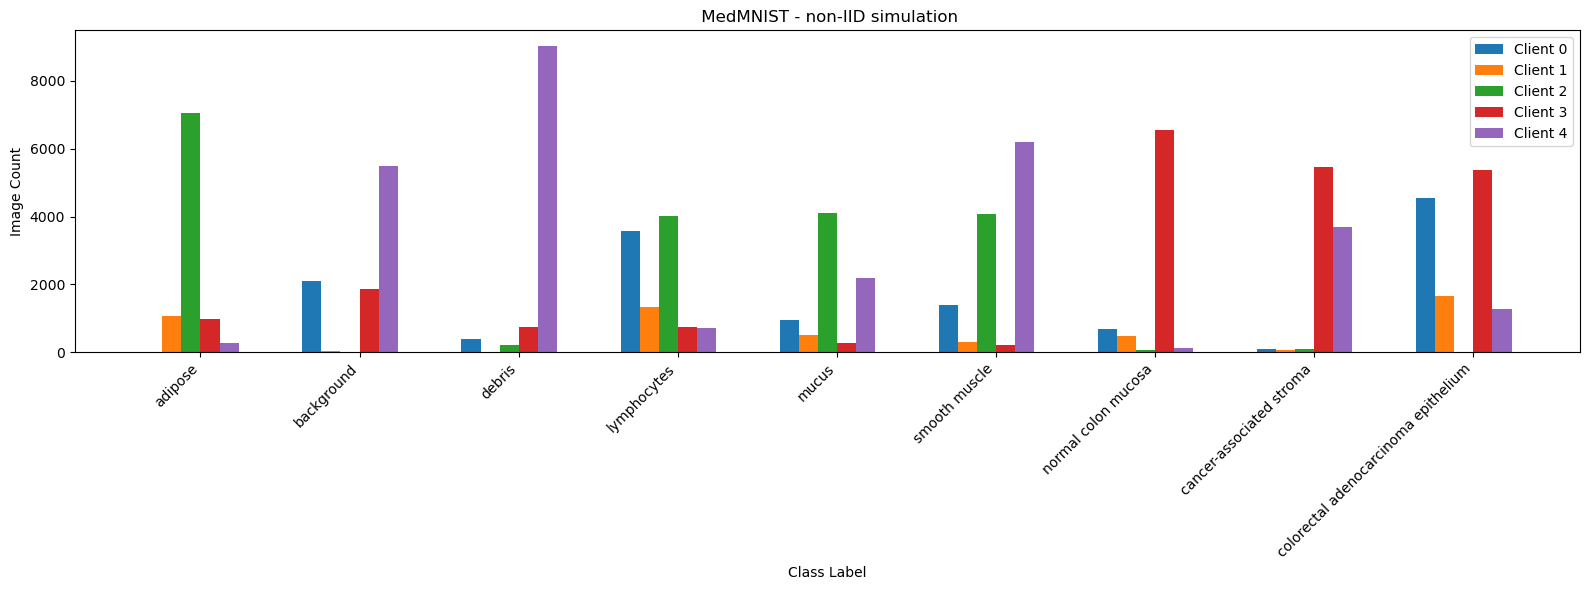

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from torchvision import transforms
from medmnist import INFO
import medmnist

# ---- Config ----
DATA_FLAG = "pathmnist"   
NUM_CLIENTS = 5
ALPHA = 0.3               
SEED = 42
BUDGET_PER_CLIENT = None  

# ---- Load dataset ----
info = INFO[DATA_FLAG]
DataClass = getattr(medmnist, info["python_class"])
transform = transforms.ToTensor()
dataset = DataClass(split="train", transform=transform, download=True)

# number of classes and names
n_classes = len(info["label"])
class_names = [info["label"][str(i)] for i in range(n_classes)]

# ---- Group indices by class (labels are scalars for PathMNIST) ----
class_to_indices = {c: [] for c in range(n_classes)}
for idx in range(len(dataset)):
    _, y = dataset[idx]
    # y is a scalar for PathMNIST; cast to int just in case
    cls = int(y)
    class_to_indices[cls].append(idx)

# shuffle within each class for randomness
rng = np.random.default_rng(SEED)
for c in class_to_indices:
    rng.shuffle(class_to_indices[c])

# ---- Dirichlet partitioning across clients ----
client_indices = [[] for _ in range(NUM_CLIENTS)]

for c in range(n_classes):
    idxs = class_to_indices[c]
    n = len(idxs)
    if n == 0:
        continue

    # draw proportions for this class across clients
    props = rng.dirichlet([ALPHA] * NUM_CLIENTS)

    
    raw = props * n
    floors = np.floor(raw).astype(int)
    remainder = n - floors.sum()
    order = np.argsort(-(raw - floors))  # largest fractional parts first
    floors[order[:remainder]] += 1
    counts = floors

    # slice class indices and assign
    start = 0
    for cid, take in enumerate(counts):
        if take > 0:
            client_indices[cid].extend(idxs[start:start + take])
            start += take

# optional: cap per-client budget (keeps plots lighter on huge sets)
if BUDGET_PER_CLIENT is not None:
    for cid in range(NUM_CLIENTS):
        rng.shuffle(client_indices[cid])
        client_indices[cid] = client_indices[cid][:BUDGET_PER_CLIENT]

# ---- Summarize and plot per-client class distribution ----
client_counts = []
for cid in range(NUM_CLIENTS):
    labels = [int(dataset[i][1]) for i in client_indices[cid]]
    client_counts.append(Counter(labels))

fig, ax = plt.subplots(figsize=(16, 6))
width = 0.12
x = np.arange(n_classes)

for i, cnt in enumerate(client_counts):
    values = [cnt.get(lbl, 0) for lbl in range(n_classes)]
    ax.bar(x + i * width, values, width=width, label=f"Client {i}")

ax.set_xticks(x + width * NUM_CLIENTS / 2)
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_xlabel("Class Label")
ax.set_ylabel("Image Count")
ax.set_title(" MedMNIST - non-IID simulation")
ax.legend()
plt.tight_layout()
plt.show()


FASHIONMNIST DATASET

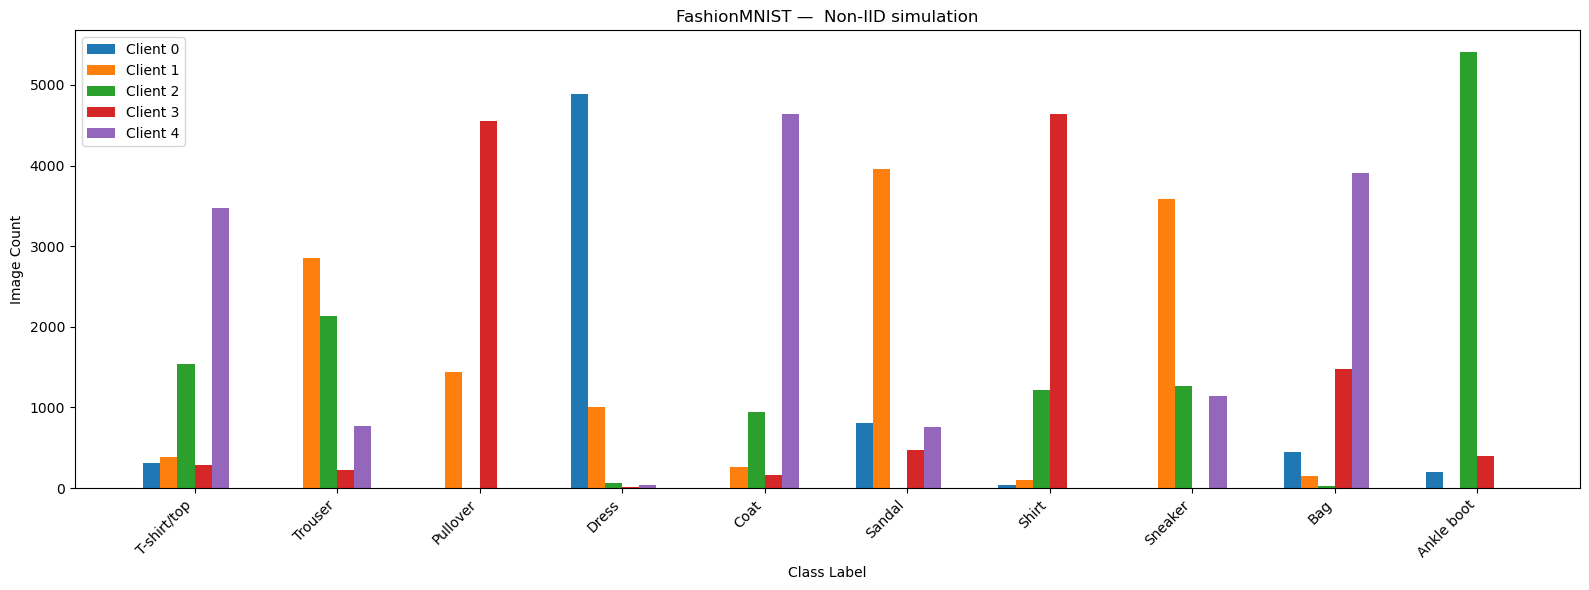

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from torchvision import datasets, transforms

# ---------------- Config ----------------
NUM_CLIENTS = 5
ALPHA = 0.3         
SEED = 42
BUDGET_PER_CLIENT = None   
# ----------------------------------------

transform = transforms.Compose([transforms.ToTensor()])
dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
N_CLASSES = len(class_names)

# ---- Group indices by class ----
class_to_indices = {c: [] for c in range(N_CLASSES)}
for idx in range(len(dataset)):
    _, y = dataset[idx]
    class_to_indices[int(y)].append(idx)

# Shuffle inside each class for randomness
rng = np.random.default_rng(SEED)
for c in class_to_indices:
    rng.shuffle(class_to_indices[c])

# ---- Dirichlet partitioning across clients ----
client_indices = [[] for _ in range(NUM_CLIENTS)]

for c in range(N_CLASSES):
    idxs = class_to_indices[c]
    n = len(idxs)
    if n == 0:
        continue

    # draw proportions for this class across clients
    props = rng.dirichlet([ALPHA] * NUM_CLIENTS)

    # convert proportions to exact counts that sum to n (stable rounding)
    raw = props * n
    floors = np.floor(raw).astype(int)
    remainder = n - floors.sum()
    order = np.argsort(-(raw - floors))  # largest fractional parts first
    floors[order[:remainder]] += 1
    counts = floors

    # assign slices to clients
    start = 0
    for cid, take in enumerate(counts):
        if take > 0:
            client_indices[cid].extend(idxs[start:start + take])
            start += take

# Optional: cap samples per client (useful for quick tests)
if BUDGET_PER_CLIENT is not None:
    for cid in range(NUM_CLIENTS):
        rng.shuffle(client_indices[cid])
        client_indices[cid] = client_indices[cid][:BUDGET_PER_CLIENT]

# ---- Summarize and plot per-client class distribution ----
client_counts = []
for cid in range(NUM_CLIENTS):
    labels = [int(dataset[i][1]) for i in client_indices[cid]]
    client_counts.append(Counter(labels))

fig, ax = plt.subplots(figsize=(16, 6))
width = 0.12
x = np.arange(N_CLASSES)

for i, cnt in enumerate(client_counts):
    values = [cnt.get(lbl, 0) for lbl in range(N_CLASSES)]
    ax.bar(x + i * width, values, width=width, label=f'Client {i}')

ax.set_xticks(x + width * NUM_CLIENTS / 2)
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_xlabel('Class Label')
ax.set_ylabel('Image Count')
ax.set_title(f'FashionMNIST —  Non-IID simulation')
ax.legend()
plt.tight_layout()
plt.show()


COMPARATIVE ACCURACY PLOTS FOR ALL 5 DATASETS 

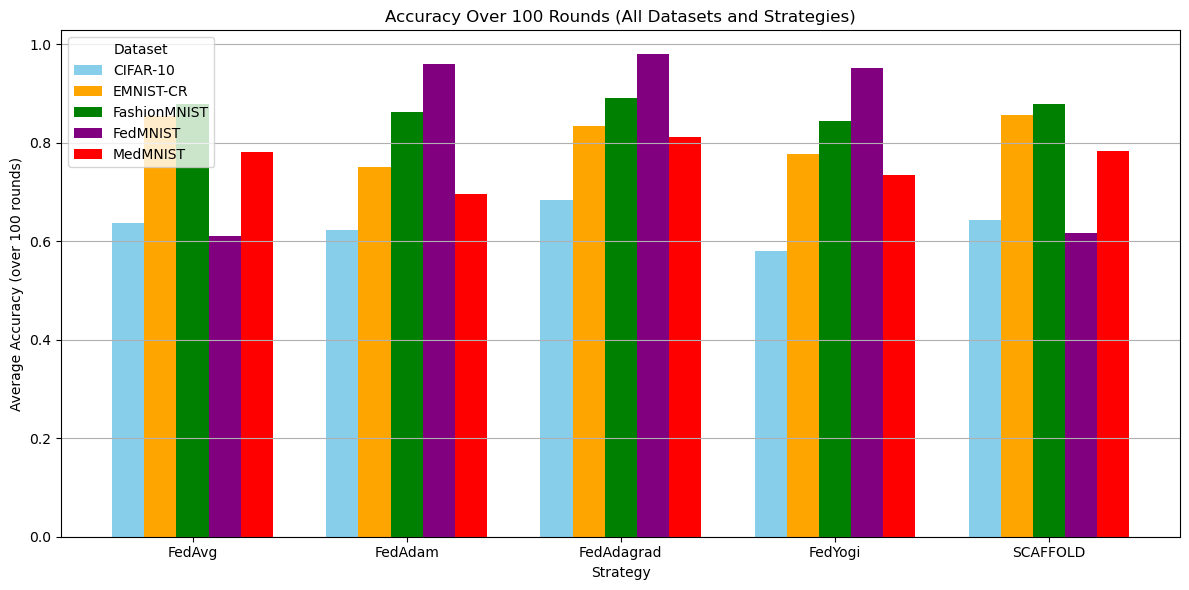

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Load and average accuracy arrays 
def load_avg(path):
    return np.mean(np.load(path)[:100])

# Dataset-wise dictionary of paths
paths = {
    "CIFAR-10": {
        "FedAvg": "fedavg_cifar10_test_accuracies.npy",
        "FedAdam": "fedadam_final_test_accuracies.npy",
        "FedAdagrad": "fedadagrad_test_accuracies.npy",
        "FedYogi": "fedyogi_cifar10_accuracies.npy",
        "SCAFFOLD": "scaffold_cifar10_test_accuracies.npy"
    },
    "EMNIST-CR": {
        "FedAvg": "emnistcr_fedavg_test_accuracies.npy",
        "FedAdam": "emnistcr_fedadam_test_accuracies.npy",
        "FedAdagrad": "emnistcr_fedadagrad_test_accuracies.npy",
        "FedYogi": "emnistcr_byclass_fedyogi_test_accuracies.npy",
        "SCAFFOLD": "scaffold_emnist_test_accuracies.npy"
    },
    "FashionMNIST": {
        "FedAvg": "fashionmnist_fedavg_test_accuracies.npy",
        "FedAdam": "fashionmnist_test_accuracies.npy",
        "FedAdagrad": "fashionmnist_fedadagrad_test_accuracies.npy",
        "FedYogi": "fashionmnist_fedyogi_accuracies.npy",
        "SCAFFOLD": "scaffold_fashionmnist_test_accuracies.npy"
    },
    "FedMNIST": {
        "FedAvg": "fedavg_fedmnist_test_accuracies.npy",
        "FedAdam": "fedadam_fedmnist_accuracies.npy",
        "FedAdagrad": "fedmnist_fedadagrad_test_accuracies.npy",
        "FedYogi": "fedmnist_fedyogi_accuracies.npy",
        "SCAFFOLD": "scaffold_fedmnist_test_accuracies.npy"
    },
    "MedMNIST": {
        "FedAvg": "medmnist_fedavg_test_accuracies.npy",
        "FedAdam": "medmnist_test_accuracies.npy",
        "FedAdagrad": "medmnist_fedadagrad_test_accuracies.npy",
        "FedYogi": "medmnist_fedyogi_accuracies.npy",
        "SCAFFOLD": "scaffold_medmnist_test_accuracies.npy"
    }
}

strategies = ["FedAvg", "FedAdam", "FedAdagrad", "FedYogi", "SCAFFOLD"]
datasets = list(paths.keys())

# Bar positions
bar_width = 0.15
x = np.arange(len(strategies))

# Colors for datasets
colors = {
    "CIFAR-10": "skyblue",
    "EMNIST-CR": "orange",
    "FashionMNIST": "green",
    "FedMNIST": "purple",
    "MedMNIST": "red"
}

# Plot
plt.figure(figsize=(12, 6))

for i, dataset in enumerate(datasets):
    accs = [load_avg(paths[dataset][s]) for s in strategies]
    plt.bar(x + i * bar_width, accs, width=bar_width, label=dataset, color=colors[dataset])

# Formatting
plt.xticks(x + 2 * bar_width, strategies)
plt.xlabel("Strategy")
plt.ylabel("Average Accuracy (over 100 rounds)")
plt.title("Accuracy Over 100 Rounds (All Datasets and Strategies)")
plt.legend(title="Dataset")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("strategy_comparison_barplot_accuracy.png")
plt.show()


COMPARATIVE LOSS PLOTS FOR ALL 5 DATASETS 

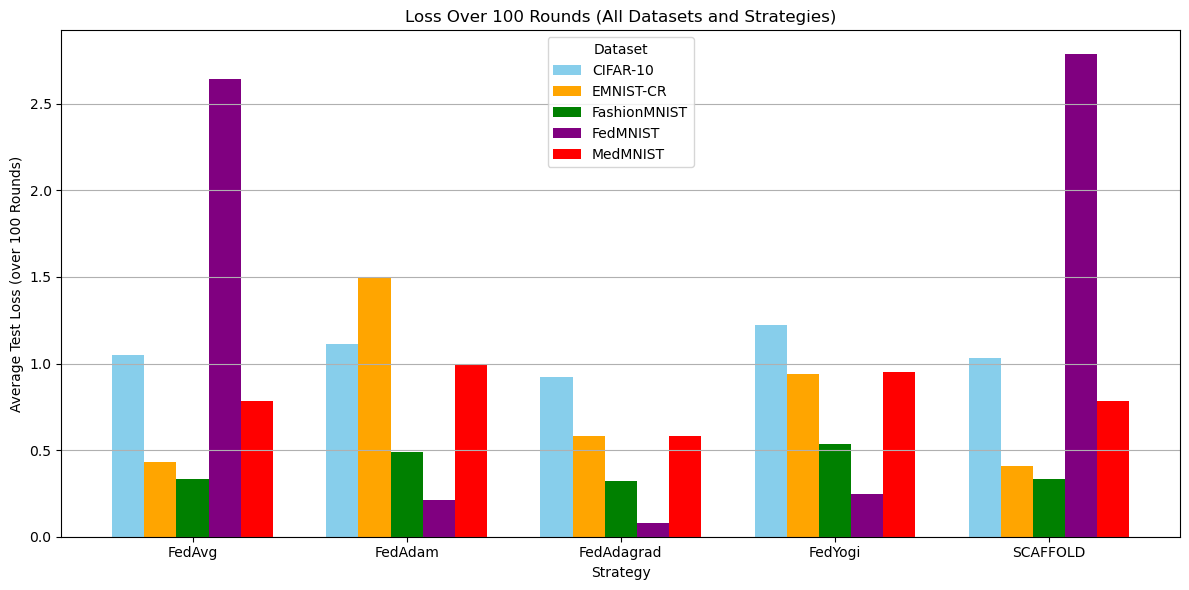

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Load and average loss arrays
def load_avg_loss(path):
    return np.mean(np.load(path)[:100])

# Dataset-wise dictionary of loss file paths
loss_paths = {
    "CIFAR-10": {
        "FedAvg": "fedavg_cifar10_test_losses.npy",
        "FedAdam": "fedadam_final_test_losses.npy",
        "FedAdagrad": "fedadagrad_test_losses.npy",
        "FedYogi": "fedyogi_cifar10_losses.npy",
        "SCAFFOLD": "scaffold_cifar10_test_losses.npy"
    },
    "EMNIST-CR": {
        "FedAvg": "emnistcr_fedavg_test_losses.npy",
        "FedAdam": "emnistcr_fedadam_test_losses.npy",
        "FedAdagrad": "emnistcr_fedadagrad_test_losses.npy",
        "FedYogi": "emnistcr_byclass_fedyogi_test_losses.npy",
        "SCAFFOLD": "scaffold_emnist_test_losses.npy"
    },
    "FashionMNIST": {
        "FedAvg": "fashionmnist_fedavg_test_losses.npy",
        "FedAdam": "fashionmnist_test_losses.npy",
        "FedAdagrad": "fashionmnist_fedadagrad_test_losses.npy",
        "FedYogi": "fashionmnist_fedyogi_losses.npy",
        "SCAFFOLD": "scaffold_fashionmnist_test_losses.npy"
    },
    "FedMNIST": {
        "FedAvg": "fedavg_fedmnist_test_losses.npy",
        "FedAdam": "fedadam_fedmnist_losses.npy",
        "FedAdagrad": "fedmnist_fedadagrad_test_losses.npy",
        "FedYogi": "fedmnist_fedyogi_losses.npy",
        "SCAFFOLD": "scaffold_fedmnist_test_losses.npy"
    },
    "MedMNIST": {
        "FedAvg": "medmnist_fedavg_test_losses.npy",
        "FedAdam": "medmnist_test_losses.npy",
        "FedAdagrad": "medmnist_fedadagrad_test_losses.npy",
        "FedYogi": "medmnist_fedyogi_losses.npy",
        "SCAFFOLD": "scaffold_medmnist_test_losses.npy"
    }
}

strategies = ["FedAvg", "FedAdam", "FedAdagrad", "FedYogi", "SCAFFOLD"]
datasets = list(loss_paths.keys())

# Bar settings
bar_width = 0.15
x = np.arange(len(strategies))

# Bar colors for each dataset
colors = {
    "CIFAR-10": "skyblue",
    "EMNIST-CR": "orange",
    "FashionMNIST": "green",
    "FedMNIST": "purple",
    "MedMNIST": "red"
}

# Plot bar chart
plt.figure(figsize=(12, 6))

for i, dataset in enumerate(datasets):
    losses = [load_avg_loss(loss_paths[dataset][s]) for s in strategies]
    plt.bar(x + i * bar_width, losses, width=bar_width, label=dataset, color=colors[dataset])

# Formatting
plt.xticks(x + 2 * bar_width, strategies)
plt.xlabel("Strategy")
plt.ylabel("Average Test Loss (over 100 Rounds)")
plt.title("Loss Over 100 Rounds (All Datasets and Strategies)")
plt.legend(title="Dataset")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("strategy_comparison_barplot_loss.png")
plt.show()
